# Ticker summary statistics
**Problem:** Get a quick risk/return profile for a single fund before looking at it in more detail.
**Approach:** Pull the full price history with `yfinance`, inspect `describe()`, holders and dividends, then compute annualised return, volatility, Sharpe ratio and max drawdown from daily close-to-close returns.
**Data:** Public Yahoo Finance data for the Vanguard growth ETF `VGRO.TO`.
**Metrics module:** `summary_stats` comes from `data-science/scripts/risk_metrics.py`, a small local module (annualised return, volatility, Sharpe ratio, max drawdown). No external course code is needed.

In [1]:
%matplotlib inline

import yfinance as yf
import matplotlib.pyplot as plt
import sys
sys.path.append('../../scripts')  # local risk_metrics module (data-science/scripts/)
import risk_metrics as rm

In [2]:
ticker = "VGRO.TO"

In [3]:
stock = yf.Ticker(ticker)

In [4]:
stockHistory = stock.history(period="max")

In [5]:
stockHistory.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
count,2173.000000,2173.000000,2173.000000,2173.000000,2.173000e+03,2173.000000,2173.000000,2173.0
mean,29.294930,29.376536,29.175961,29.283226,1.279637e+05,0.002481,0.000457,0.0
std,7.530765,7.549197,7.509261,7.533647,8.204318e+04,0.020591,0.021302,0.0
min,18.134254,18.431824,17.959214,18.134254,1.210000e+04,0.000000,0.000000,0.0
25%,23.085999,23.157934,23.012970,23.063246,7.680000e+04,0.000000,0.000000,0.0
50%,27.805571,27.885714,27.689595,27.801664,1.093000e+05,0.000000,0.000000,0.0
75%,33.724937,33.859984,33.474118,33.676697,1.532000e+05,0.000000,0.000000,0.0
max,48.439999,48.540001,48.360001,48.459999,1.058400e+06,0.274000,0.993000,0.0


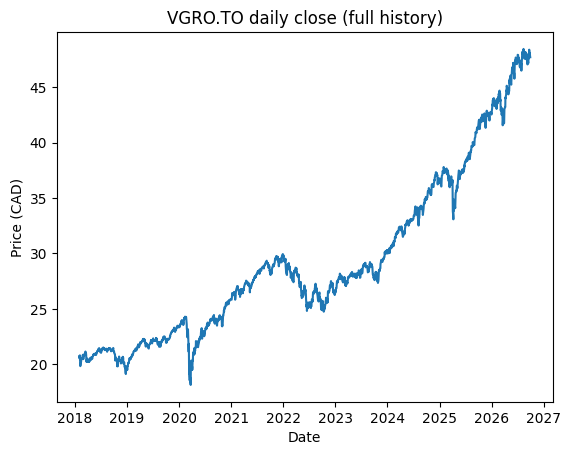

In [6]:
plt.plot(stockHistory.index, stockHistory["Close"])
plt.title(f"{ticker} daily close (full history)")
plt.xlabel("Date")
plt.ylabel("Price (CAD)");

In [7]:
stock.major_holders

""


In [8]:
stock.dividends

Date
2018-06-22 09:30:00-04:00    0.136
2018-09-28 09:30:00-04:00    0.137
2018-12-28 09:30:00-05:00    0.138
2019-03-29 09:30:00-04:00    0.122
2019-06-28 09:30:00-04:00    0.173
2019-09-30 09:30:00-04:00    0.131
2019-12-30 09:30:00-05:00    0.161
2020-03-31 09:30:00-04:00    0.094
2020-06-30 09:30:00-04:00    0.155
2020-09-30 09:30:00-04:00    0.141
2020-12-30 09:30:00-05:00    0.130
2021-03-31 09:30:00-04:00    0.125
2021-06-30 09:30:00-04:00    0.151
2021-09-29 09:30:00-04:00    0.138
2021-12-30 09:30:00-05:00    0.181
2022-03-31 09:30:00-04:00    0.109
2022-06-30 09:30:00-04:00    0.178
2022-09-29 09:30:00-04:00    0.155
2022-12-29 09:30:00-05:00    0.173
2023-04-03 09:30:00-04:00    0.136
2023-07-05 09:30:00-04:00    0.189
2023-09-29 09:30:00-04:00    0.154
2023-12-28 09:30:00-05:00    0.210
2024-04-01 09:30:00-04:00    0.221
2024-07-02 09:30:00-04:00    0.274
2024-10-01 09:30:00-04:00    0.108
2024-12-30 09:30:00-05:00    0.156
2025-04-01 09:30:00-04:00    0.175
2025-07-02 09:3

## Risk/return summary from daily returns

In [9]:
r = stockHistory[['Close']].pct_change()  # daily returns of the close price

In [10]:
rm.summary_stats(r, riskfree_rate=0.03, periods_per_year=253)

,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown
Close,0.102072,0.124876,0.560399,-0.253603
